# LangGraph Streaming

<b>Streaming: </b> <i>LangGraph implements a streaming system to surface real-time updates. Streaming is crucial for enhancing the responsiveness of applications built on LLMs. By displaying output progressively, even before a complete response is ready, streaming significantly improves user experience (UX), particularly when dealing with the latency of LLMs. </i>

In [1]:
%%capture
!pip install langgraph
!pip install mermaid-py  # to visualise the graph

Documentation:
*  https://docs.langchain.com/oss/python/langgraph/streaming

In [34]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
import time
from IPython.display import Image
from datetime import datetime


In [46]:
def get_time_stamp():
  return str(datetime.now()).split(".")[0]

In [50]:
# creating class to define the state for graph
class GraphState(TypedDict):
  topic: str    # to store the topic info
  details: str  # to store the details about topic
  timestamp: str


# node to modify the topic entry
def refine_topic(graphState: GraphState):
  return {"topic": "What is " + graphState["topic"] + " ?", "timestamp": get_time_stamp()}


# node to get the details for the topic
def get_details(graphState: GraphState):
  time.sleep(3) # keeping sleep here to understand the stream concept
  return {"details": f"Here is the details about the entered topic: {graphState['topic']}", "timestamp": get_time_stamp()}


In [51]:
# construting a graph with node and edges
graph = StateGraph(GraphState)

graph.add_node(refine_topic)
graph.add_node(get_details)
graph.add_edge(START, "refine_topic")
graph.add_edge("refine_topic", "get_details")
graph.add_edge("get_details", END)

workflow = graph.compile()


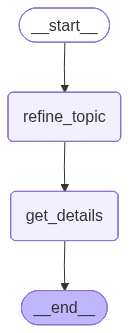

In [38]:
# let's llok into our graph
Image(workflow.get_graph().draw_mermaid_png())

Perfect!!! Now, let's see how invoke  vs stream works

In [52]:
# invoke waits and produces the final output
output = workflow.invoke({"topic": "langgraph stream", "timestamp": get_time_stamp()})
print(output)

{'topic': 'What is langgraph stream ?', 'details': 'Here is the details about the entered topic: What is langgraph stream ?', 'timestamp': '2025-11-12 08:16:47'}


Nice, so here we have observed that we are getting timestamp at final even though the execution started and produced output, we got the final output at the end only.

Let's see how stream works

### stream_mode

Stream comes with multiple modes as below:

*  **values:**	Streams the full value of the state after each step of the graph.

*  **updates:**	Streams the updates to the state after each step of the graph. If multiple updates are made in the same step (e.g., multiple nodes are run), those updates are streamed separately.

*  **custom:** Streams custom data from inside your graph nodes.

*  **messages:**	Streams 2-tuples (LLM token, metadata) from any graph nodes where an LLM is invoked.

*  **debug:**	Streams as much information as possible throughout the execution of the graph.

In [53]:
# stream mode as values - it shows the state updated values

for chunk in workflow.stream(
    {"topic": f"langgraph stream", "timestamp": get_time_stamp()},
    stream_mode="values",
):
    print(chunk)

{'topic': 'langgraph stream', 'timestamp': '2025-11-12 08:16:47'}
{'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:16:47'}
{'topic': 'What is langgraph stream ?', 'details': 'Here is the details about the entered topic: What is langgraph stream ?', 'timestamp': '2025-11-12 08:16:50'}


In [54]:
# stream mode as updates - it shows all the udpates at node level
for chunk in workflow.stream(
    {"topic": "langgraph stream", "timestamp": get_time_stamp()},
    stream_mode="updates",
):
    print(chunk)

{'refine_topic': {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:16:50'}}
{'get_details': {'details': 'Here is the details about the entered topic: What is langgraph stream ?', 'timestamp': '2025-11-12 08:16:53'}}


In [57]:
# stream mode as devug - it shows detailed activity as it goes
for chunk in workflow.stream(
    {"topic": "langgraph stream", "timestamp": get_time_stamp()},
    stream_mode="debug",
):
    print(chunk)

{'step': 1, 'timestamp': '2025-11-12T08:18:29.091571+00:00', 'type': 'task', 'payload': {'id': '857bf7a2-448a-ca16-1d9c-7efff9b4fed5', 'name': 'refine_topic', 'input': {'topic': 'langgraph stream', 'timestamp': '2025-11-12 08:18:29'}, 'triggers': ('branch:to:refine_topic',)}}
{'step': 1, 'timestamp': '2025-11-12T08:18:29.092060+00:00', 'type': 'task_result', 'payload': {'id': '857bf7a2-448a-ca16-1d9c-7efff9b4fed5', 'name': 'refine_topic', 'error': None, 'result': {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:18:29'}, 'interrupts': []}}
{'step': 2, 'timestamp': '2025-11-12T08:18:29.092269+00:00', 'type': 'task', 'payload': {'id': 'a75af991-b2a5-c0b4-a8c0-7c7a8e79608b', 'name': 'get_details', 'input': {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:18:29'}, 'triggers': ('branch:to:get_details',)}}
{'step': 2, 'timestamp': '2025-11-12T08:18:32.092985+00:00', 'type': 'task_result', 'payload': {'id': 'a75af991-b2a5-c0b4-a8c0-7c7a8e79608b', 'name': '

we can also stream multiple modes

In [59]:
# stream mode as values - it shows the state updated values

for chunk in workflow.stream(
    {"topic": f"langgraph stream", "timestamp": get_time_stamp()},
    stream_mode=["values", "debug"]
):
    print(chunk)

('values', {'topic': 'langgraph stream', 'timestamp': '2025-11-12 08:20:59'})
('debug', {'step': 1, 'timestamp': '2025-11-12T08:20:59.115721+00:00', 'type': 'task', 'payload': {'id': '8bc0eacc-83e3-1961-cafe-f276ae9df04f', 'name': 'refine_topic', 'input': {'topic': 'langgraph stream', 'timestamp': '2025-11-12 08:20:59'}, 'triggers': ('branch:to:refine_topic',)}})
('debug', {'step': 1, 'timestamp': '2025-11-12T08:20:59.117040+00:00', 'type': 'task_result', 'payload': {'id': '8bc0eacc-83e3-1961-cafe-f276ae9df04f', 'name': 'refine_topic', 'error': None, 'result': {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:20:59'}, 'interrupts': []}})
('values', {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:20:59'})
('debug', {'step': 2, 'timestamp': '2025-11-12T08:20:59.117329+00:00', 'type': 'task', 'payload': {'id': 'a84e9b9d-8859-caa9-0e43-210b5c9c9621', 'name': 'get_details', 'input': {'topic': 'What is langgraph stream ?', 'timestamp': '2025-11-12 08:20: